# Karachi AQI - Exploratory Data Analysis

This notebook explores the engineered feature table (`data/features_targets.csv`)
produced by the feature pipeline, to understand:

1. Overall data quality and coverage
2. How AQI trends over time
3. Daily / weekly / monthly seasonality
4. Which pollutants and weather variables correlate most with AQI
5. The distribution of AQI categories (Good / Moderate / ... / Hazardous)

Run this after `backfill_historical.py` + `build_features.py` have produced
a reasonably large `features_targets.csv` (at least a few weeks of hourly data
gives much more meaningful seasonality plots than a few days).

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 4)
sns.set_style("whitegrid")

DATA_PATH = "../data/features_targets.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp_utc"])
df = df.sort_values("timestamp_utc").reset_index(drop=True)
print(f"Loaded {len(df)} rows spanning {df['timestamp_utc'].min()} to {df['timestamp_utc'].max()}")
df.head()

Loaded 3996 rows spanning 2026-03-05 11:00:00+00:00 to 2026-08-29 10:00:00+00:00


,timestamp_utc,city,lat,lon,temp_c,humidity_pct,wind_speed_ms,pressure_hpa,weather_main,aqi_openweather,...,aqi_lag_1h,aqi_lag_3h,aqi_lag_24h,aqi_roll_mean_3h,aqi_roll_mean_24h,aqi_roll_std_24h,pm_ratio,target_aqi_24h,target_aqi_48h,target_aqi_72h
0,2026-03-05 11:00:00+00:00,Karachi,24.8607,67.0011,26.6,53.0,16.7,1011.3,NaN,3.0,...,NaN,NaN,NaN,82.300000,82.300,NaN,0.457531,117.5,76.7,71.1
1,2026-03-05 12:00:00+00:00,Karachi,24.8607,67.0011,25.6,61.0,16.6,1011.1,NaN,3.0,...,82.3,NaN,NaN,82.500000,82.500,0.282843,0.460116,118.0,75.9,71.1
2,2026-03-05 13:00:00+00:00,Karachi,24.8607,67.0011,24.6,68.0,16.0,1011.3,NaN,3.0,...,82.7,NaN,NaN,82.700000,82.700,0.400000,0.463544,117.5,75.1,71.4
3,2026-03-05 14:00:00+00:00,Karachi,24.8607,67.0011,23.7,76.0,14.1,1011.5,NaN,3.0,...,83.1,82.3,NaN,83.066667,82.875,0.478714,0.467466,115.9,74.3,71.8
4,2026-03-05 15:00:00+00:00,Karachi,24.8607,67.0011,23.3,82.0,11.8,1011.7,NaN,3.0,...,83.4,82.7,NaN,83.366667,83.020,0.526308,0.471789,113.5,73.4,72.2


## 1. Data overview & quality check

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3996 entries, 0 to 3995
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   timestamp_utc      3996 non-null   datetime64[ns, UTC]
 1   city               3996 non-null   object             
 2   lat                3996 non-null   float64            
 3   lon                3996 non-null   float64            
 4   temp_c             3912 non-null   float64            
 5   humidity_pct       3912 non-null   float64            
 6   wind_speed_ms      3912 non-null   float64            
 7   pressure_hpa       3912 non-null   float64            
 8   weather_main       0 non-null      float64            
 9   aqi_openweather    3912 non-null   float64            
 10  pm2_5              3912 non-null   float64            
 11  pm10               3912 non-null   float64            
 12  no2                3912 non-null   float64      

In [14]:
print("Missing values per column:")
missing = df.isna().sum()
missing[missing > 0]

Missing values per column:


temp_c                84
humidity_pct          84
wind_speed_ms         84
pressure_hpa          84
weather_main        3996
aqi_openweather       84
pm2_5                 84
pm10                  84
no2                   84
so2                   84
co                    84
o3                    84
nh3                   84
aqi_us_epa            84
aqi_aqicn           3996
aqi_change_rate       89
aqi_lag_1h            85
aqi_lag_3h            87
aqi_lag_24h          108
aqi_roll_mean_3h      76
aqi_roll_std_24h       1
pm_ratio              84
dtype: int64

In [15]:
df[["aqi_us_epa", "pm2_5", "pm10", "no2", "so2", "co", "o3",
    "temp_c", "humidity_pct", "wind_speed_ms"]].describe()

,aqi_us_epa,pm2_5,pm10,no2,so2,co,o3,temp_c,humidity_pct,wind_speed_ms
count,3912.000000,3912.000000,3912.000000,3912.000000,3912.000000,3912.000000,3912.000000,3912.000000,3912.000000,3912.000000
mean,75.387926,21.766552,81.369676,0.092629,0.414169,89.708971,56.562994,28.762470,73.209131,12.962186
std,26.840973,10.656575,41.818296,0.045936,0.176864,23.404919,24.202855,2.860334,13.849026,4.166280
min,16.900000,3.050000,5.930000,0.020000,0.060000,62.690000,29.690000,17.700000,7.000000,0.500000
25%,61.575000,14.710000,56.790000,0.060000,0.300000,70.460000,40.367500,27.200000,66.000000,10.100000
50%,72.000000,20.000000,77.350000,0.080000,0.400000,76.560000,45.510000,28.900000,75.000000,13.300000
75%,84.325000,26.702500,102.897500,0.110000,0.510000,112.777500,70.090000,30.500000,83.000000,15.900000
max,500.000000,112.910000,647.240000,0.490000,1.600000,152.990000,149.490000,41.200000,99.000000,25.000000


## 2. AQI trend over time

The raw hourly series, plus a 24h rolling average to smooth out hour-to-hour
noise and make the underlying trend easier to read.

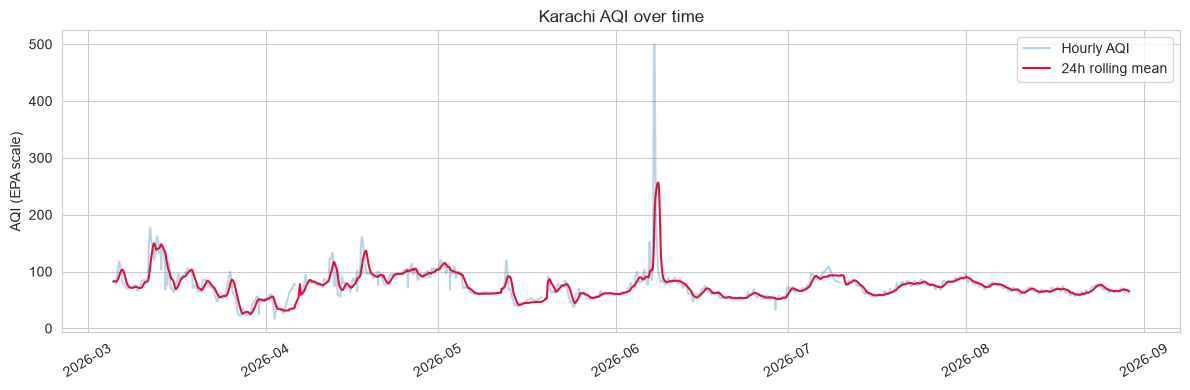

In [16]:
fig, ax = plt.subplots()
ax.plot(df["timestamp_utc"], df["aqi_us_epa"], alpha=0.3, label="Hourly AQI")
ax.plot(df["timestamp_utc"], df["aqi_us_epa"].rolling(24, min_periods=1).mean(),
        color="crimson", label="24h rolling mean")
ax.set_ylabel("AQI (EPA scale)")
ax.set_title("Karachi AQI over time")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Seasonality patterns

Does AQI follow a daily rhythm (e.g. worse during traffic hours), a weekly
one (weekday vs weekend), or a monthly one (seasonal burning, weather
patterns)? Boxplots make outliers and spread visible, not just the average.

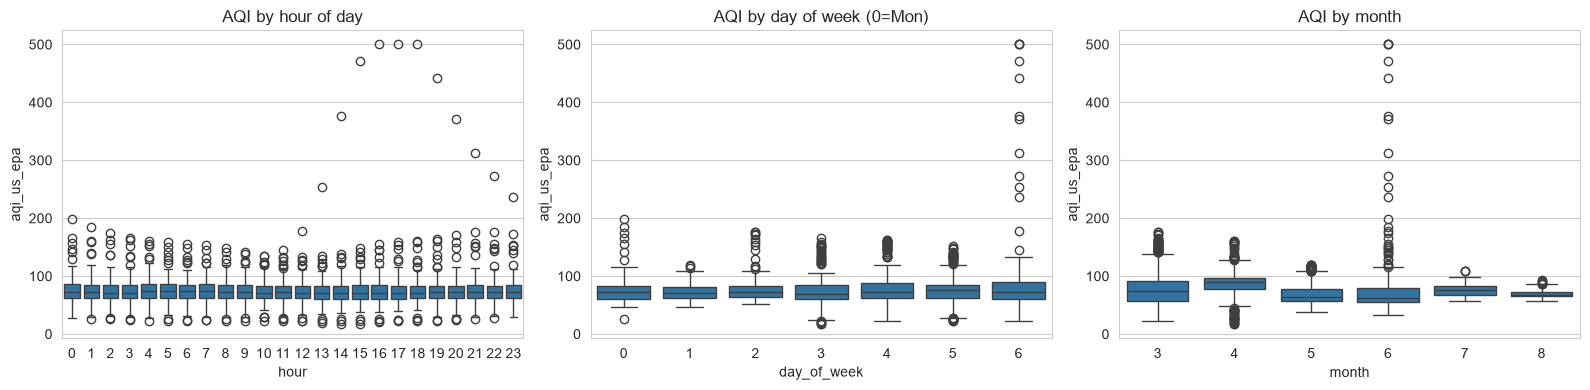

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x="hour", y="aqi_us_epa", ax=axes[0])
axes[0].set_title("AQI by hour of day")

sns.boxplot(data=df, x="day_of_week", y="aqi_us_epa", ax=axes[1])
axes[1].set_title("AQI by day of week (0=Mon)")

sns.boxplot(data=df, x="month", y="aqi_us_epa", ax=axes[2])
axes[2].set_title("AQI by month")

plt.tight_layout()
plt.show()

In [18]:
weekend_comparison = df.groupby("is_weekend")["aqi_us_epa"].agg(["mean", "median", "std"])
weekend_comparison.index = weekend_comparison.index.map({0: "Weekday", 1: "Weekend"})
weekend_comparison

,mean,median,std
is_weekend,,,
Weekday,74.236175,71.3,20.041452
Weekend,78.388848,73.3,39.238844


## 4. What correlates with AQI?

A correlation heatmap across pollutants, weather variables, and AQI itself.
Note that PM2.5 and PM10 feed directly into how `aqi_us_epa` is computed, so
their strong correlation is expected - the more informative signal here is
which *weather* variables (temp, humidity, wind, pressure) move AQI, since
those aren't circular.

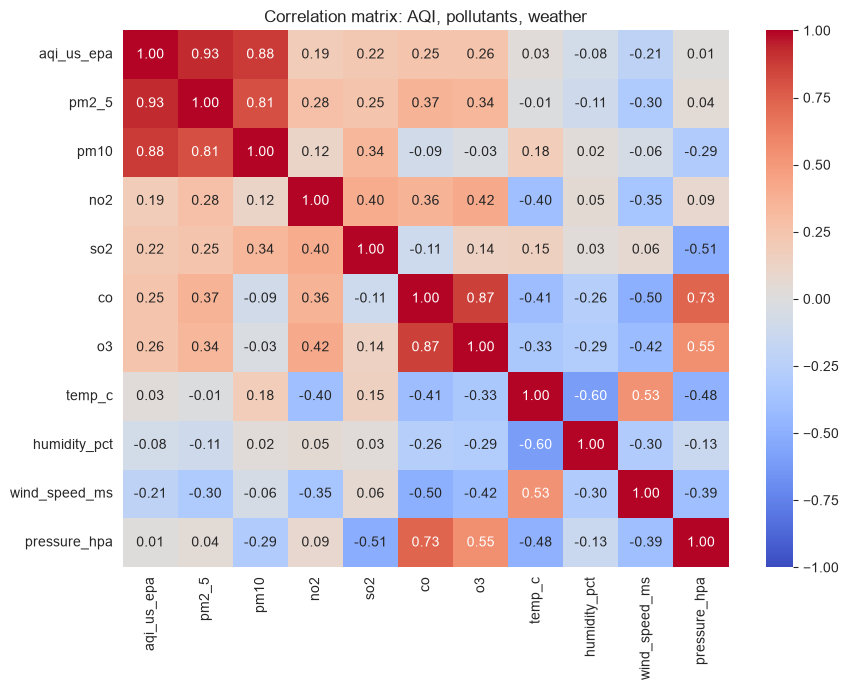

In [19]:
corr_cols = ["aqi_us_epa", "pm2_5", "pm10", "no2", "so2", "co", "o3",
             "temp_c", "humidity_pct", "wind_speed_ms", "pressure_hpa"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix: AQI, pollutants, weather")
plt.tight_layout()
plt.show()

In [20]:
corr["aqi_us_epa"].drop("aqi_us_epa").sort_values(key=abs, ascending=False)

pm2_5            0.928047
pm10             0.880724
o3               0.255471
co               0.250554
so2              0.222620
wind_speed_ms   -0.214993
no2              0.192870
humidity_pct    -0.078824
temp_c           0.027570
pressure_hpa     0.007980
Name: aqi_us_epa, dtype: float64

## 5. AQI category distribution

Using the same EPA breakpoints the web app uses, so this matches what
users will actually see on the dashboard.

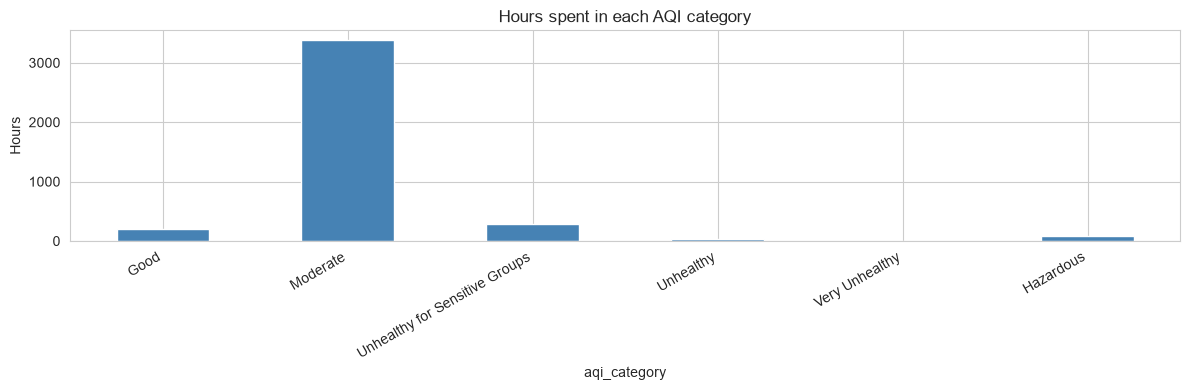


10.4% of hours were Unhealthy-for-Sensitive-Groups or worse


In [21]:
def categorize(aqi):
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Moderate"
    if aqi <= 150: return "Unhealthy for Sensitive Groups"
    if aqi <= 200: return "Unhealthy"
    if aqi <= 300: return "Very Unhealthy"
    return "Hazardous"

category_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups",
                   "Unhealthy", "Very Unhealthy", "Hazardous"]

df["aqi_category"] = df["aqi_us_epa"].apply(categorize)
category_counts = df["aqi_category"].value_counts().reindex(category_order).fillna(0)

ax = category_counts.plot(kind="bar", color="steelblue")
ax.set_ylabel("Hours")
ax.set_title("Hours spent in each AQI category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"\n{(df['aqi_category'].isin(['Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous'])).mean()*100:.1f}% "
      "of hours were Unhealthy-for-Sensitive-Groups or worse")

## 6. How fast does AQI change hour to hour?

This matters for the forecast horizons: if AQI is highly volatile,
72h-ahead predictions are inherently harder than 24h-ahead ones.

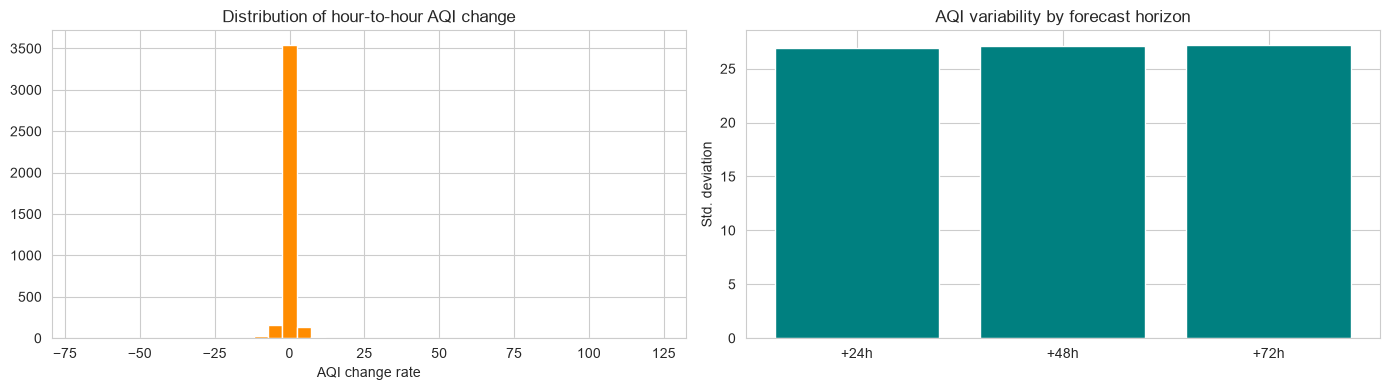

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["aqi_change_rate"].dropna(), bins=40, color="darkorange")
axes[0].set_title("Distribution of hour-to-hour AQI change")
axes[0].set_xlabel("AQI change rate")

horizon_std = {
    "+24h": df["target_aqi_24h"].std() if "target_aqi_24h" in df else np.nan,
    "+48h": df["target_aqi_48h"].std() if "target_aqi_48h" in df else np.nan,
    "+72h": df["target_aqi_72h"].std() if "target_aqi_72h" in df else np.nan,
}
axes[1].bar(horizon_std.keys(), horizon_std.values(), color="teal")
axes[1].set_title("AQI variability by forecast horizon")
axes[1].set_ylabel("Std. deviation")

plt.tight_layout()
plt.show()

## 7. Summary

Findings from the real Karachi dataset (3,996 hourly rows, 2026-03-05 to 2026-08-29):

- **Overall AQI**: mean 75.4 (EPA "Moderate"), std 26.8, ranging from 16.9 up
  to 500 (the Hazardous ceiling was actually reached at least once). **10.4%
  of all hours were Unhealthy-for-Sensitive-Groups (AQI >= 151) or worse** -
  a meaningful real-world rate for the dashboard's hazard-alert feature to
  actually matter.
- **Dominant pollutant**: PM2.5 correlates far more strongly with AQI
  (r=0.928) than PM10 (r=0.881) - consistent with PM2.5 usually being the
  binding pollutant in the EPA formula for Karachi's typical concentrations.
  Among weather variables, wind speed has the strongest relationship
  (r=-0.215, more wind -> lower AQI, i.e. dispersion) - temperature and
  pressure are negligible (|r| < 0.03).
- **Seasonality**: median AQI is fairly stable across March-August, but
  **June stands out clearly** - the widest spread and by far the most
  extreme high outliers (several days reaching 400-500), while July and
  August are comparatively calm with tight, low-outlier boxes. This is a
  direct, visual confirmation of the seasonal regime shift diagnosed during
  model training: a model trained across the full March-August span
  struggled to generalize to the calmer July-August test period, and
  restricting training to a recent 45-day window (mostly excluding June's
  volatility) was what let Ridge finally beat a naive persistence baseline.
- **Weekday vs weekend**: weekends actually show a *higher* mean (78.4 vs
  74.2) and much higher std (39.2 vs 20.0) than weekdays - but this is driven
  by a handful of extreme Sunday outliers reaching up to 500, not a
  systematic weekend effect. No clear rush-hour cycle appears in the
  hour-of-day boxplot either - median AQI is essentially flat across all 24
  hours, with occasional afternoon/evening spikes.
- **Hour-to-hour volatility**: AQI usually changes very little hour to hour
  (tightly centered on 0), punctuated by rare large jumps - consistent with
  the extreme outlier events seen above being sudden, short-lived spikes
  rather than gradual drift.
- **Data quality note**: `weather_main` is 100% missing across the *entire*
  dataset, not just the backfilled portion - meaning the live hourly fetch
  isn't successfully capturing OpenWeather's weather description either.
  This doesn't affect the AQI forecast itself (weather_main was never used
  as a model feature), but it's worth investigating in `fetch_raw_data.py`'s
  `fetch_weather()` if a textual weather condition is ever wanted for the
  dashboard.